# Initial figures

First exploratory figures from the README's *Future Figures* list.

- **A.1** Deployment overview stack: buoy Hs, Tp and Dp, tide, sea-swell Hs at every Vector, subtidal current speed and wind, with swell events shaded.
- **A.2** Hourly pressure spectrogram per Vector (log f × time), with the same events marked.

Notes:
- Vectors only. The Paros aren't QC'd yet, and the ADCP sits next to VC10.
- All times are UTC.
- Figures are saved to `figs/initial/`.
- The small inputs (buoy, wind, hourly spectra) are cached on the first run, so later runs skip the downloads and the ~790 MB QC files.

Kernel: **Python (analysiz)**.

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from scipy.signal import welch

# ---- paths ----
QC_DIR   = '../data/processed/qc'     # {S}_QC.nc, adv_bulk512.csv
META_DIR = '../data/metadata'         # NOAA files, cached buoy / wind
FIG_DIR  = '../figs/initial'
os.makedirs(FIG_DIR, exist_ok=True)

# ---- sensors (west -> east, deep -> shallow within a transect) ----
SENSORS = ['VA10', 'VB5', 'VC10', 'VC5', 'VD10', 'VD5', 'VE10', 'VE7', 'VE4']
TRANSECTS = 'ABCDE'

# ---- time window: the Vector record ----
T0, T1 = pd.Timestamp('2026-07-19'), pd.Timestamp('2026-09-16')

# ---- physics ----
RHO, G = 1025.0, 9.81                 # seawater density [kg/m^3], gravity [m/s^2]
FS = 2.0                              # Vector sample rate [Hz]

## Style

- Two anchor colors: IndianRed and cobalt blue (`#0047AB`).
- Transects are colored along a ramp from IndianRed (A, west) to cobalt (E, east).
- Line style shows depth: 10 m is solid, 7 m is dash-dot, and 4–5.5 m is dashed.

In [2]:
RED, BLUE = 'indianred', '#0047AB'
ramp = LinearSegmentedColormap.from_list('red_blue', [RED, BLUE])
T_COLOR = {t: ramp(i / (len(TRANSECTS) - 1)) for i, t in enumerate(TRANSECTS)}   # A red ... E blue

def depth_of(S):
    return int(S[2:])                       # 'VE10' -> 10

def style(S):
    # line color and style for one sensor: color = transect, line style = depth class
    d  = depth_of(S)
    ls = '-' if d >= 10 else ('-.' if d >= 7 else '--')
    return dict(color=T_COLOR[S[1]], ls=ls, lw=1.0)

# Clean look: no top/right spines, small fonts, no grid.
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.6, 'axes.labelsize': 9, 'axes.titlesize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'legend.fontsize': 8, 'legend.frameon': False, 'font.family': 'sans-serif',
})

## Inputs

### Buoy: CDIP 238 (Barbers Point, Kalaeloa)
- Hs, peak period Tp and peak direction Dp (direction waves come **from**, deg true).
- Only records with `waveFlagPrimary == 1` (good) are kept.
- The buoy sits about 12 km west of the array, offshore of Barbers Point.
- The subset is downloaded once and cached to `data/metadata/cdip238_waves.csv`.

In [3]:
BUOY_CSV = f'{META_DIR}/cdip238_waves.csv'
if not os.path.exists(BUOY_CSV):
    url = 'https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/238p1_rt.nc'
    with xr.open_dataset(url) as b:
        b = b[['waveHs', 'waveTp', 'waveDp', 'waveFlagPrimary']].sel(waveTime=slice('2026-07-18', '2026-09-17'))
        b = b.to_dataframe()[['waveHs', 'waveTp', 'waveDp', 'waveFlagPrimary']]
    b = b[b.waveFlagPrimary == 1].drop(columns='waveFlagPrimary')
    b.index.name = 'time'
    b.columns = ['Hs', 'Tp', 'Dp']
    b.to_csv(BUOY_CSV)
buoy = pd.read_csv(BUOY_CSV, index_col='time', parse_dates=True)
buoy.describe().round(2)

,Hs,Tp,Dp
count,2976.00,2976.00,2976.00
mean,1.13,14.23,191.25
std,0.54,2.47,14.97
min,0.50,4.76,147.37
25%,0.85,12.50,183.51
50%,1.01,14.29,190.27
75%,1.28,15.38,195.99
max,7.79,22.22,320.30


### Tide and wind: NOAA 1612340 (Honolulu)
- The water level comes from the local file. The file does not name its datum, so the axis reads "water level (m)".
- Hourly wind is downloaded once from the CO-OPS API (GMT) and cached to `data/metadata/noaa_1612340_wind.csv`.
- Honolulu Harbor is about 20 km east of Ewa and sheltered, so its wind is only a rough guide to local wind.

In [4]:
tide = pd.read_csv(f'{META_DIR}/noaa_1612340_water_level.csv', index_col=0, parse_dates=True)
tide = tide.iloc[:, 0].rename('eta')                       # 'Water Level' [m], 6-min

WIND_CSV = f'{META_DIR}/noaa_1612340_wind.csv'
if not os.path.exists(WIND_CSV):
    url = ('https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=wind&station=1612340'
           '&begin_date=20260718&end_date=20260917&time_zone=gmt&units=metric&interval=h&format=csv')
    pd.read_csv(url).to_csv(WIND_CSV, index=False)
wind = pd.read_csv(WIND_CSV, index_col=0, parse_dates=True)
wind.columns = wind.columns.str.strip()
wind = wind[['Speed', 'Direction']].rename(columns={'Speed': 'spd', 'Direction': 'dir'})   # m/s, deg from
wind = wind.apply(pd.to_numeric, errors='coerce')
print(f"wind: {len(wind)} h, mean {wind.spd.mean():.1f} m/s, "
      f"median direction from {wind.dir.median():.0f}° true")

wind: 1488 h, mean 2.3 m/s, median direction from 67° true


### Sea-swell Hs at each Vector
- This is the hourly `Hs_SS` from each `{S}_QC.nc`: the depth-corrected pressure spectrum over 0.04–0.25 Hz.
- It is the same product that `adv_QCBulk.ipynb` checked against the 512 s Hs.
- Only the `hour`-dimension variables are read, so this step is quick.

In [5]:
hs = {}
for S in SENSORS:
    with xr.open_dataset(f'{QC_DIR}/{S}_QC.nc') as ds:
        hs[S] = ds.Hs_SS.to_series()
hs = pd.DataFrame(hs)
hs.describe().round(2)

,VA10,VB5,VC10,VC5,VD10,VD5,VE10,VE7,VE4
count,1412.00,1388.00,1390.00,1410.00,1390.00,1415.00,1389.00,1419.00,1416.00
mean,1.32,1.30,1.28,1.13,1.01,1.02,1.00,0.95,0.96
std,0.52,0.45,0.50,0.36,0.44,0.34,0.41,0.32,0.29
min,0.59,0.61,0.55,0.50,0.43,0.47,0.38,0.41,0.46
25%,0.98,0.98,0.95,0.88,0.78,0.80,0.76,0.74,0.76
50%,1.19,1.18,1.14,1.03,0.93,0.95,0.92,0.89,0.89
75%,1.58,1.59,1.51,1.35,1.17,1.19,1.17,1.11,1.14
max,5.49,3.21,4.44,2.29,4.92,2.81,4.67,2.57,2.22


### Subtidal current speed
1. Start from the 512 s mean `u` and `v` in `adv_bulk512.csv`, and average them to hourly values.
2. Fill gaps of up to 3 h by linear interpolation.
3. Low-pass each component with a Godin filter (24 h, 24 h and 25 h running means).
4. Compute speed as $\sqrt{u^2 + v^2}$.

Speed does not depend on the rotation, so the loose-head sensors (VB5, VE4, VE7) are fine here.

In [6]:
bulk = pd.read_csv(f'{QC_DIR}/adv_bulk512.csv', parse_dates=['time'])

def godin(x):
    # Godin low-pass on an hourly series: running means of 24, 24 and 25 h
    for n in (24, 24, 25):
        x = x.rolling(n, center=True).mean()
    return x

spd = {}
for S in SENSORS:
    b  = bulk[bulk.sensor == S].set_index('time')[['u', 'v']]
    hr = b.resample('1h').mean().interpolate(limit=3, limit_area='inside')
    lp = hr.apply(godin)
    spd[S] = np.hypot(lp.u, lp.v)
spd = pd.DataFrame(spd)
spd.describe().round(3)

,VA10,VB5,VC10,VC5,VD10,VD5,VE10,VE7,VE4
count,1344.000,1320.000,1322.000,1342.000,1322.000,1347.000,1321.000,1349.000,1348.000
mean,0.014,0.063,0.027,0.058,0.029,0.030,0.027,0.019,0.038
std,0.012,0.023,0.015,0.039,0.018,0.016,0.017,0.012,0.034
min,0.000,0.007,0.001,0.010,0.002,0.000,0.004,0.002,0.002
25%,0.007,0.047,0.016,0.035,0.016,0.019,0.014,0.011,0.014
50%,0.010,0.064,0.023,0.050,0.023,0.028,0.022,0.016,0.030
75%,0.017,0.075,0.035,0.068,0.037,0.041,0.037,0.025,0.050
max,0.059,0.148,0.071,0.286,0.097,0.097,0.076,0.069,0.190


## Swell events
The rule is in one cell so it is easy to change. It is applied to the **mean sea-swell Hs of the four 10 m Vectors** (VA10, VC10, VD10, VE10). That puts the events at Ewa itself, rather than at the buoy, whose exposure is different.

- An event is a run where the hourly reference Hs is at or above its `EVENT_PCT` percentile for at least `EVENT_MIN_H` hours.
- Runs separated by less than `EVENT_GAP_H` hours are merged into one event.

In [7]:
EVENT_PCT   = 75     # percentile of reference Hs
EVENT_MIN_H = 12     # minimum duration [h]
EVENT_GAP_H = 6      # merge runs separated by less than this [h]

hs_ref = hs[['VA10', 'VC10', 'VD10', 'VE10']].mean(axis=1)
thr    = np.nanpercentile(hs_ref, EVENT_PCT)
above  = hs_ref >= thr

# contiguous runs of 'above'
runs = []
for _, grp in above[above].groupby((~above).cumsum()):
    runs.append([grp.index[0], grp.index[-1] + pd.Timedelta('1h')])

# merge runs separated by short gaps, then keep the long ones
merged = []
for r in runs:
    if merged and r[0] - merged[-1][1] < pd.Timedelta(hours=EVENT_GAP_H):
        merged[-1][1] = r[1]
    else:
        merged.append(r)
EVENTS = [(a, b) for a, b in merged if b - a >= pd.Timedelta(hours=EVENT_MIN_H)]

print(f'reference Hs threshold ({EVENT_PCT}th pct): {thr:.2f} m')
pd.DataFrame([{'start': a, 'end': b, 'hours': (b - a) / pd.Timedelta('1h'),
               'peak Hs_ref (m)': round(hs_ref[a:b].max(), 2)} for a, b in EVENTS])

reference Hs threshold (75th pct): 1.37 m


,start,end,hours,peak Hs_ref (m)
0,2026-07-20 16:00:00,2026-07-21 19:00:00,27.0,1.55
1,2026-07-22 08:00:00,2026-07-25 14:00:00,78.0,1.86
2,2026-07-26 06:00:00,2026-07-26 19:00:00,13.0,1.44
3,2026-08-13 07:00:00,2026-08-15 05:00:00,46.0,1.78
4,2026-08-15 21:00:00,2026-08-18 07:00:00,58.0,3.25
5,2026-08-28 05:00:00,2026-08-29 01:00:00,20.0,1.61
6,2026-09-02 22:00:00,2026-09-05 15:00:00,65.0,1.85
7,2026-09-07 15:00:00,2026-09-10 06:00:00,63.0,4.77


In [8]:
def shade_events(ax):
    # light IndianRed band behind every event
    for a, b in EVENTS:
        ax.axvspan(a, b, color=RED, alpha=0.12, lw=0, zorder=0)

## A.1 Deployment overview stack
*Which events are worth a case study?*

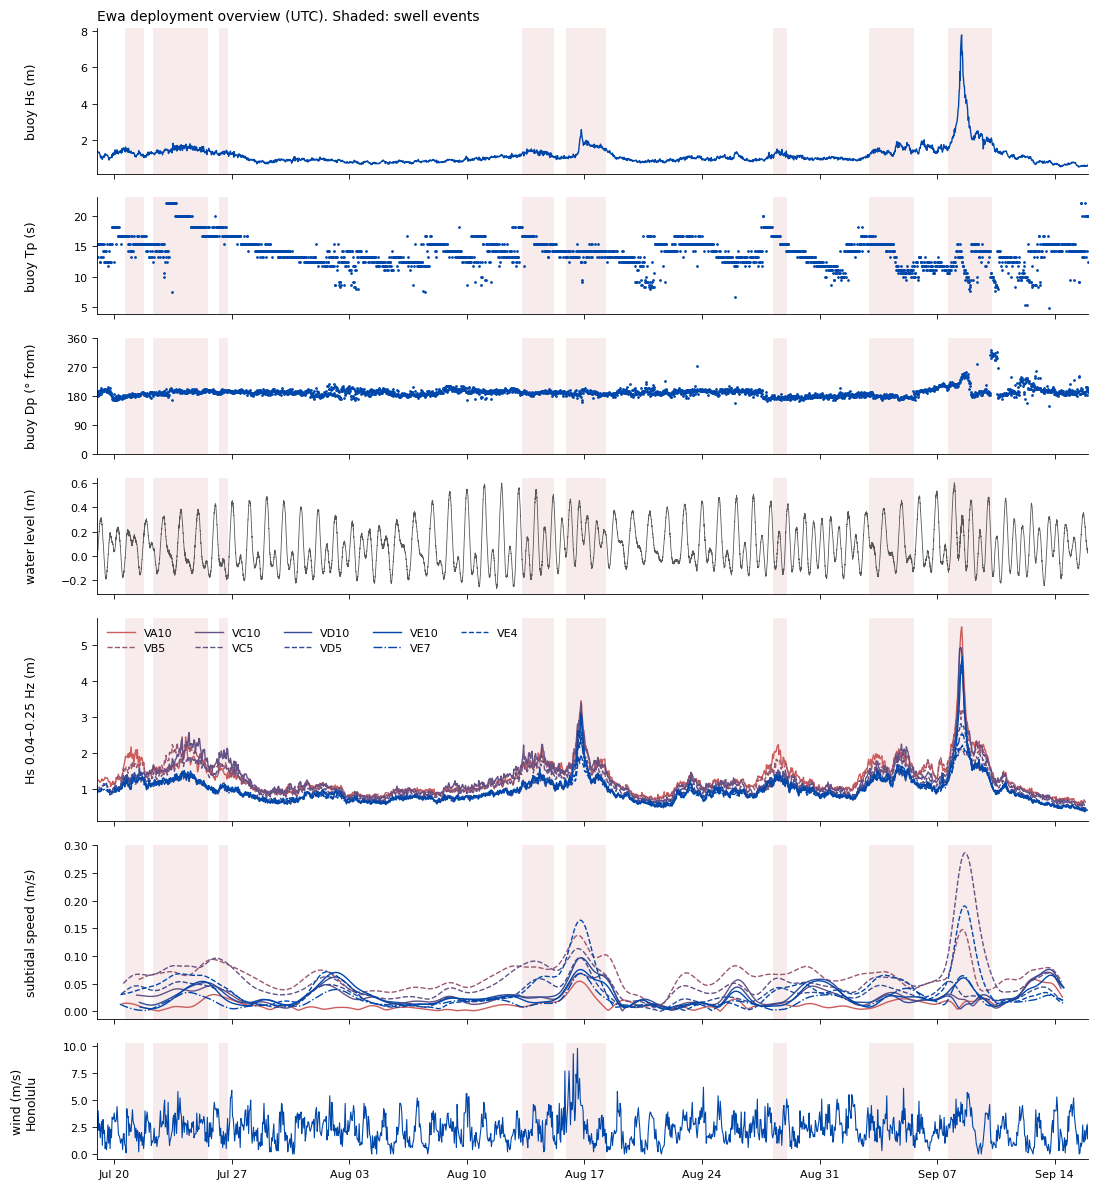

In [9]:
fig, axs = plt.subplots(7, 1, figsize=(11, 12), sharex=True,
                        gridspec_kw=dict(height_ratios=[1, 0.8, 0.8, 0.8, 1.4, 1.2, 0.8]))

# 1-3: buoy
axs[0].plot(buoy.index, buoy.Hs, color=BLUE, lw=1)
axs[0].set_ylabel('buoy Hs (m)')
axs[1].plot(buoy.index, buoy.Tp, '.', ms=2, color=BLUE)
axs[1].set_ylabel('buoy Tp (s)')
axs[2].plot(buoy.index, buoy.Dp, '.', ms=2, color=BLUE)
axs[2].set_ylabel('buoy Dp (° from)')
axs[2].set_yticks([0, 90, 180, 270, 360])

# 4: tide
axs[3].plot(tide.index, tide, color='0.35', lw=0.6)
axs[3].set_ylabel('water level (m)')

# 5: sea-swell Hs at each Vector
for S in SENSORS:
    axs[4].plot(hs.index, hs[S], label=S, **style(S))
axs[4].set_ylabel('Hs 0.04–0.25 Hz (m)')
axs[4].legend(ncol=5, loc='upper left', handlelength=2.5)

# 6: subtidal current speed
for S in SENSORS:
    axs[5].plot(spd.index, spd[S], **style(S))
axs[5].set_ylabel('subtidal speed (m/s)')

# 7: wind
axs[6].plot(wind.index, wind.spd, color=BLUE, lw=0.8)
axs[6].set_ylabel('wind (m/s)\nHonolulu')

for ax in axs:
    shade_events(ax)
    ax.yaxis.set_label_coords(-0.06, 0.5)        # line the y-labels up
axs[-1].set_xlim(T0, T1)
axs[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axs[0].set_title('Ewa deployment overview (UTC). Shaded: swell events', loc='left')

fig.align_ylabels(axs)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/A1_overview.png', dpi=200)
plt.show()

## A.2 Pressure spectrogram per sensor
*Do arrivals differ across the array, which would mean refraction or sheltering?*

Each clock hour gets a Welch spectrum of pressure head (m of water):
- 512 s windows (df ≈ 0.002 Hz), 50 % overlap, linear detrend.
- Hours with less than 99 % of their samples are skipped.

The spectrum is **not** depth-corrected to η. The cosh correction blows up at high f, and arrival timing and frequency drift don't need it.

Only `p` is loaded, one sensor at a time. The result is cached to `data/processed/qc/adv_Spp_hourly.nc`.

In [10]:
SPP_NC  = f'{QC_DIR}/adv_Spp_hourly.nc'
NPERSEG = 1024                       # 512 s windows
N_HOUR  = int(3600 * FS)

if not os.path.exists(SPP_NC):
    out = []
    for S in SENSORS:
        with xr.open_dataset(f'{QC_DIR}/{S}_QC.nc') as ds:
            p = ds.p.to_series() * 1e4 / (RHO * G)          # dbar -> m of water
        hours, specs = [], []
        for t, seg in p.groupby(pd.Grouper(freq='1h')):
            seg = seg.dropna()
            if len(seg) < 0.99 * N_HOUR:
                continue
            f, S_ = welch(seg.to_numpy(), fs=FS, nperseg=NPERSEG, detrend='linear')
            hours.append(t); specs.append(S_)
        out.append(xr.DataArray(np.array(specs), dims=('hour', 'freq'),
                                coords={'hour': hours, 'freq': f}).expand_dims(sensor=[S]))
        print(f'{S:5s} {len(hours)} hours')
    Spp = xr.concat(out, dim='sensor').rename('Spp')
    Spp.attrs = {'units': 'm^2/Hz', 'long_name': 'hourly pressure-head PSD (not depth corrected)',
                 'method': f'Welch, nperseg={NPERSEG} (512 s), 50% overlap, linear detrend; hours with <99% samples skipped'}
    Spp.to_netcdf(SPP_NC)

Spp = xr.open_dataarray(SPP_NC)
Spp

<xarray.DataArray 'Spp' (sensor: 9, hour: 1419, freq: 513)> Size: 52MB
[6551523 values with dtype=float64]
Coordinates:
  * hour     (hour) datetime64[ns] 11kB 2026-07-18T20:00:00 ... 2026-09-15T22...
  * freq     (freq) float64 4kB 0.0 0.001953 0.003906 ... 0.9961 0.998 1.0
  * sensor   (sensor) <U4 144B 'VA10' 'VB5' 'VC10' 'VC5' ... 'VE10' 'VE7' 'VE4'
Attributes:
    units:      m^2/Hz
    long_name:  hourly pressure-head PSD (not depth corrected)
    method:     Welch, nperseg=1024 (512 s), 50% overlap, linear detrend; hou...

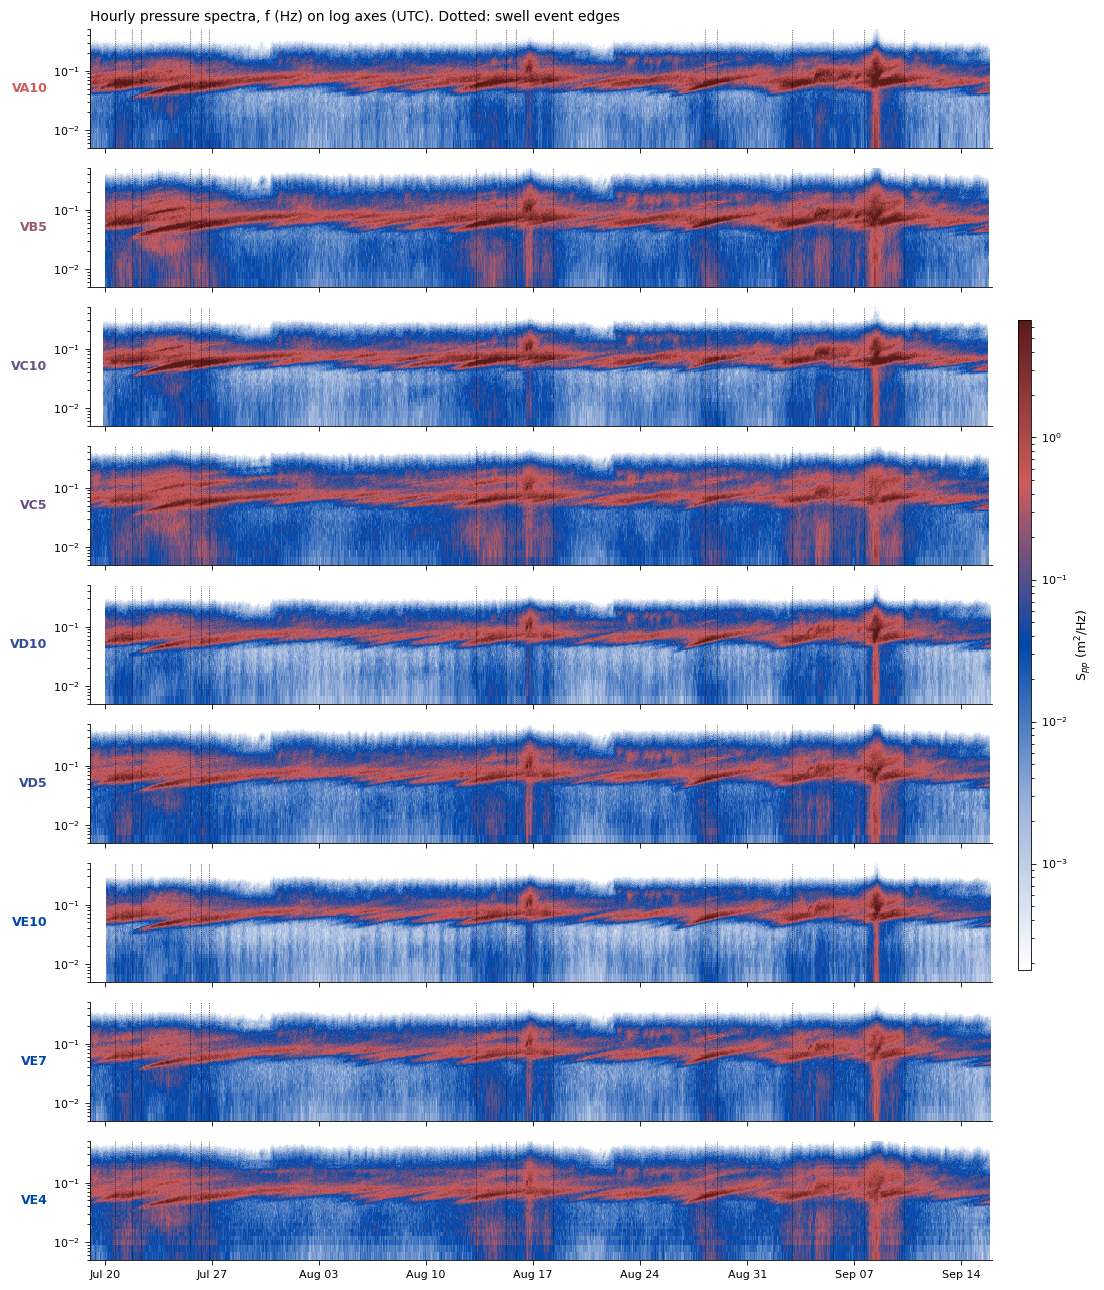

In [11]:
FMIN, FMAX = 0.004, 0.5                          # plotted band [Hz]
cmap = LinearSegmentedColormap.from_list('spec', ['white', '#9DB4DA', BLUE, RED, '#5A1A1A'])
spec = Spp.sel(freq=slice(FMIN, FMAX))
norm = LogNorm(vmin=float(spec.quantile(0.30)), vmax=float(spec.quantile(0.999)))   # same scale for all; quiet floor stays pale

fig, axs = plt.subplots(len(SENSORS), 1, figsize=(11, 13), sharex=True, sharey=True)
for ax, S in zip(axs, SENSORS):
    s = spec.sel(sensor=S).dropna('hour', how='all')
    full = s.reindex(hour=pd.date_range(s.hour[0].values, s.hour[-1].values, freq='1h'))   # gaps stay white
    pc = ax.pcolormesh(full.hour, full.freq, full.T, cmap=cmap, norm=norm, shading='nearest', rasterized=True)
    ax.set_yscale('log')
    for a, b in EVENTS:                          # event edges as thin lines, so the colors stay readable
        ax.axvline(a, color='k', lw=0.5, ls=':')
        ax.axvline(b, color='k', lw=0.5, ls=':')
    ax.set_ylabel(S, color=T_COLOR[S[1]], weight='bold', rotation=0, ha='right', va='center')

axs[-1].set_xlim(T0, T1)
axs[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axs[0].set_title('Hourly pressure spectra, f (Hz) on log axes (UTC). Dotted: swell event edges', loc='left')
fig.tight_layout(rect=(0, 0, 0.92, 1))
cax = fig.add_axes([0.93, 0.25, 0.012, 0.5])
fig.colorbar(pc, cax=cax, label='S$_{pp}$ (m$^2$/Hz)')
fig.savefig(f'{FIG_DIR}/A2_spectrogram.png', dpi=200)
plt.show()